✅ Final dataset loaded!
   player_id first_name       last_name                   name  last_season  \
0         80        Tom          Starke             Tom Starke         2017   
1        162       Marc         Ziegler           Marc Ziegler         2012   
2        277     Sérgio  da Silva Pinto  Sérgio da Silva Pinto         2013   
3        332   Benjamin          Köhler        Benjamin Köhler         2012   
4        447        Oka         Nikolov            Oka Nikolov         2012   

   current_club_id            player_code    country_of_birth  \
0               27             tom-starke  East Germany (GDR)   
1               79           marc-ziegler             Germany   
2             3368  sergio-da-silva-pinto            Portugal   
3               24        benjamin-kohler             Germany   
4               24            oka-nikolov             Germany   

        city_of_birth country_of_citizenship  ...  \
0             Freital                Germany  ...   
1   

C:\Users\saura\AppData\Local\Temp\ipykernel_22776\1285746820.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


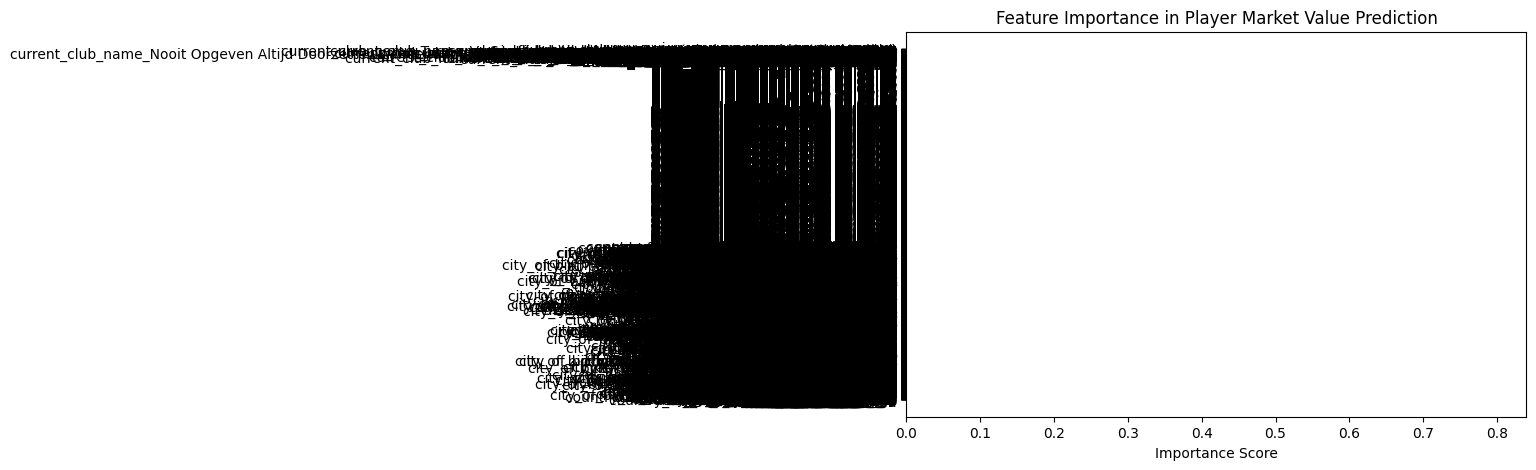

✅ Predictions saved to final_predictions_week4.csv


In [1]:
import pandas as pd

# Load your final cleaned + feature-engineered data
df = pd.read_csv("player_features_final.csv")
print("✅ Final dataset loaded!")
print(df.head())

X = df.drop(columns=["market_value_in_eur"])
y = df["market_value_in_eur"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# See which columns are still not numeric
non_numeric = X.select_dtypes(include=['object']).columns
print("🧾 Non-numeric columns:", list(non_numeric))

# Drop non-relevant columns
drop_cols = ['name', 'first_name', 'last_name', 'player_code', 'url', 'image_url', 'agent_name']
X = X.drop(columns=[col for col in drop_cols if col in X.columns], errors='ignore')

# Encode categorical columns automatically
X = pd.get_dummies(X, drop_first=True)

print("✅ After encoding, all numeric columns:")
print(X.select_dtypes(exclude=['number']).columns)  # should show nothing

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(n_estimators=80, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 Model Evaluation Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
plt.barh(feature_names, importance, color='skyblue')
plt.title("Feature Importance in Player Market Value Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

pred_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
pred_df.to_csv("final_predictions_week4.csv", index=False)
print("✅ Predictions saved to final_predictions_week4.csv")


